# NS — Reducción de dimensionalidad con PCA

**Materia:** Extracción de Conocimiento de Base de Datos
**Docente:** Filiberto Ruíz Hernández
**Alumno:** Mario Alberto Ramírez Martínez — Matrícula 2023371044
**Universidad:** Universidad Tecnológica de Querétaro — Ingeniería en Gestión de Desarrollo de Software
**Semestre:** 2026 — Fecha: 2026-08-07

---

## 4. Reducción sobre comprar_alquilar.csv

Reducir la dimensionalidad del conjunto comprar_alquilar.csv mediante Análisis de Componentes Principales (PCA), comparar los dos primeros componentes sin y con escalado de datos, y justificar el número de componentes retenido.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE = "/home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2"
DATA = os.path.join(BASE, "data/raw")
IMG = os.path.join(BASE, "reporte/img")
MODELOS = os.path.join(BASE, "modelos")
os.makedirs(IMG, exist_ok=True)
os.makedirs(MODELOS, exist_ok=True)
print("Rutas listas: DATA =", DATA)

Rutas listas: DATA = /home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2/data/raw


## Justificación del algoritmo

Se elige **PCA** porque es el método de reducción de dimensionalidad más estándar: proyecta los datos a nuevas direcciones ortogonales que capturan la mayor varianza posible. Permite visualizar datos de 9 variables predictoras en 2D, elimina redundancia y facilita modelos posteriores. La elección del número de componentes se justifica con la **varianza explicada acumulada** (umbral del 95%) y el criterio de Kaiser (autovalores > 1).

In [2]:
df = pd.read_csv(os.path.join(DATA, "comprar_alquilar.csv"))
df.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [3]:
print("Dimensiones:", df.shape)
print("\nNulos:", df.isna().sum().sum())
print("\nEstadísticos:\n", df.describe().round(2))
print("\nDistribución de 'comprar':\n", df["comprar"].value_counts())

Dimensiones: (202, 10)

Nulos: 0

Estadísticos:
        ingresos  gastos_comunes  pago_coche  gastos_otros   ahorros  \
count    202.00          202.00      202.00        202.00    202.00   
mean    4959.00          971.58      211.74        515.43  38749.67   
std     1682.86          272.11      124.94        168.10  17365.23   
min     2008.00          384.00        0.00        201.00  10319.00   
25%     3513.75          766.75       99.00        383.25  24964.25   
50%     4947.50          968.00      208.50        522.50  38523.00   
75%     6374.50         1165.25      318.75        656.75  52150.75   
max     7984.00         1585.00      448.00        828.00  69934.00   

        vivienda  estado_civil   hijos  trabajo  comprar  
count     202.00        202.00  202.00   202.00   202.00  
mean   373349.64          1.02    1.23     4.49     0.33  
std    136371.53          0.84    1.37     2.54     0.47  
min    176553.00          0.00    0.00     0.00     0.00  
25%    274810.00

## Diseño del modelo (paso a paso)

### Comparación: dos primeros componentes SIN escalar

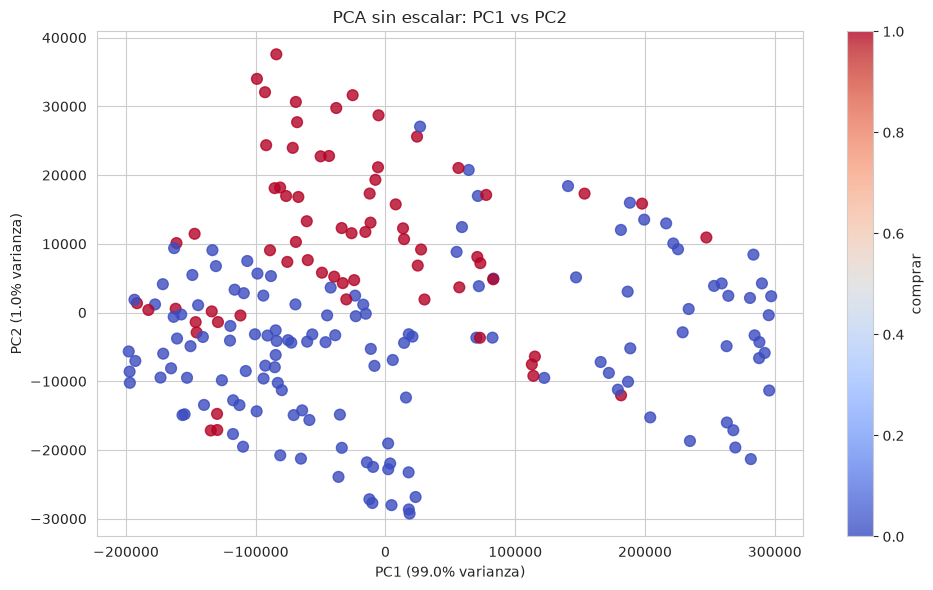

Varianza explicada (sin escalar): [0.99 0.01]


In [4]:
from sklearn.decomposition import PCA

X = df.drop(columns=["comprar"])
y = df["comprar"]

pca_sin = PCA(n_components=2, random_state=42)
Xs = pca_sin.fit_transform(X)

plt.figure()
sc = plt.scatter(Xs[:, 0], Xs[:, 1], c=y, cmap="coolwarm", s=60, alpha=0.8)
plt.xlabel(f"PC1 ({pca_sin.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca_sin.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title("PCA sin escalar: PC1 vs PC2")
plt.colorbar(sc, label="comprar"); plt.tight_layout()
plt.savefig(os.path.join(IMG, "pca_sin_escalado.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Varianza explicada (sin escalar):", pca_sin.explained_variance_ratio_.round(3))

### Comparación: dos primeros componentes CON escalado

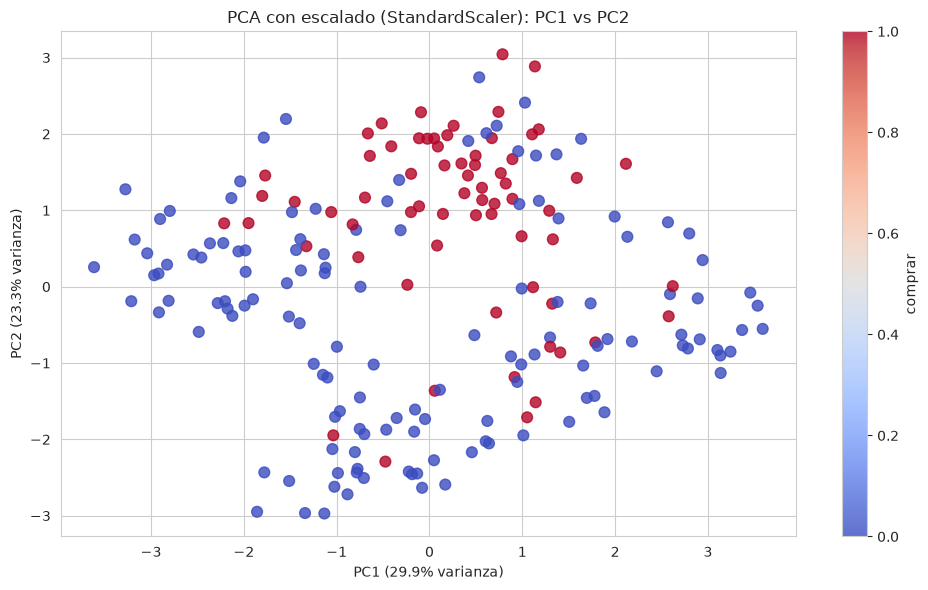

Varianza explicada (con escalado): [0.299 0.233]


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xe = scaler.fit_transform(X)

pca_con = PCA(n_components=2, random_state=42)
Xe2 = pca_con.fit_transform(Xe)

plt.figure()
sc = plt.scatter(Xe2[:, 0], Xe2[:, 1], c=y, cmap="coolwarm", s=60, alpha=0.8)
plt.xlabel(f"PC1 ({pca_con.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca_con.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title("PCA con escalado (StandardScaler): PC1 vs PC2")
plt.colorbar(sc, label="comprar"); plt.tight_layout()
plt.savefig(os.path.join(IMG, "pca_con_escalado.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Varianza explicada (con escalado):", pca_con.explained_variance_ratio_.round(3))

### ¿Por qué importa el escalado?

In [6]:
# Las variables están en unidades distintas (ingresos ~6000, vivienda ~400000):
print(df[["ingresos", "vivienda", "ahorros"]].std().round(2))
# Sin escalar, el PCA queda dominado por las variables de mayor magnitud.
# Con escalado, todas las variables pesan por igual. Por eso se justifica el uso de StandardScaler.

ingresos      1682.86
vivienda    136371.53
ahorros      17365.23
dtype: float64


## Optimización — justificación del número de componentes

In [7]:
pca_full = PCA(random_state=42).fit(Xe)
var = pca_full.explained_variance_ratio_
acum = np.cumsum(var)
n95 = np.argmax(acum >= 0.95) + 1
nkaiser = np.sum(pca_full.explained_variance_ > 1)
print("Varianza explicada por componente:", var.round(4))
print("Varianza acumulada:", acum.round(4))
print("\nComponentes para 95%% de varianza: %d" % n95)
print("Componentes con autovalor > 1 (Kaiser): %d" % nkaiser)

Varianza explicada por componente: [0.2991 0.2329 0.1171 0.1069 0.0964 0.0563 0.0415 0.0302 0.0197]
Varianza acumulada: [0.2991 0.5321 0.6492 0.7561 0.8524 0.9087 0.9502 0.9803 1.    ]

Componentes para 95% de varianza: 7
Componentes con autovalor > 1 (Kaiser): 3


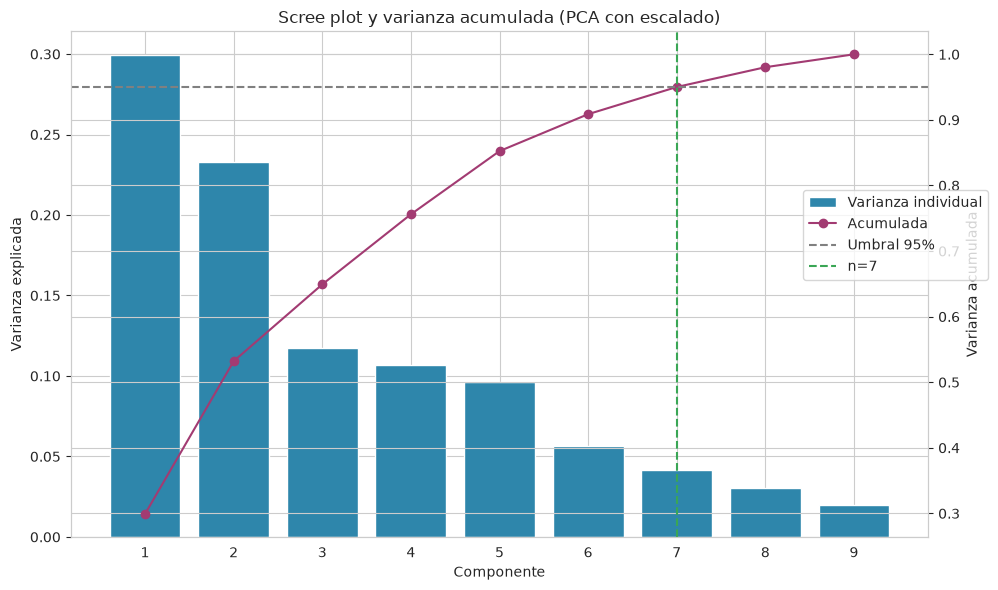

In [8]:
fig, ax1 = plt.subplots()
ax1.bar(range(1, len(var) + 1), var, color="#2E86AB", label="Varianza individual")
ax1.set_xlabel("Componente"); ax1.set_ylabel("Varianza explicada")
ax1.set_xticks(range(1, len(var) + 1))
ax2 = ax1.twinx()
ax2.plot(range(1, len(var) + 1), acum, marker="o", color="#A23B72", label="Acumulada")
ax2.axhline(0.95, ls="--", color="gray", label="Umbral 95%")
ax2.set_ylabel("Varianza acumulada")
ax2.axvline(n95, ls="--", color="#3AA655", label=f"n={n95}")
plt.title("Scree plot y varianza acumulada (PCA con escalado)")
fig.legend(loc="center right", bbox_to_anchor=(1, 0.6))
plt.tight_layout()
plt.savefig(os.path.join(IMG, "varianza_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

## Reducción final con el número de componentes elegido

In [9]:
# Se elige el número de componentes que captura al menos el 95% de la varianza.
pca_final = PCA(n_components=n95, random_state=42)
Xred = pca_final.fit_transform(Xe)
print("Datos originales:", X.shape, "-> Reducidos:", Xred.shape)
print("Varianza capturada:", acum[n95 - 1].round(4))

Datos originales: (202, 9) -> Reducidos: (202, 7)
Varianza capturada: 0.9502


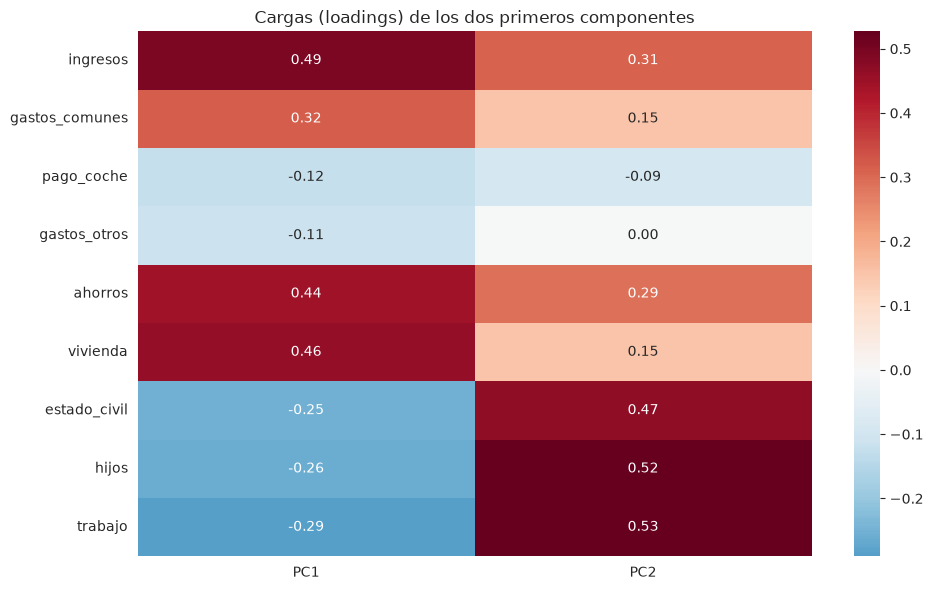

In [10]:
cargas = pd.DataFrame(pca_con.components_.T, index=X.columns, columns=["PC1", "PC2"])
plt.figure(figsize=(10, 6))
sns.heatmap(cargas, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Cargas (loadings) de los dos primeros componentes")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "loadings_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

## Guardar el modelo

In [11]:
import joblib
pipeline = {"scaler": scaler, "pca_final": pca_final, "n_components": n95}
joblib.dump(pipeline, os.path.join(MODELOS, "comprar_alquilar_pca.pkl"))
print("Modelo PCA guardado en modelos/comprar_alquilar_pca.pkl")

Modelo PCA guardado en modelos/comprar_alquilar_pca.pkl


## Verificación de integridad (recarga del modelo)

In [12]:
p = joblib.load(os.path.join(MODELOS, "comprar_alquilar_pca.pkl"))
Xv = p["scaler"].transform(X)
Xvr = p["pca_final"].transform(Xv)
print("Recarga OK — forma reducida:", Xvr.shape, "| n_components:", p["n_components"])

Recarga OK — forma reducida: (202, 7) | n_components: 7
